## Mitigating old Variational Quantum Eigensolver results

In this example, we load a pre-trained VQE, connect to the WACQT device, and demonstrate how computing an updated noise map allows us to obtain a good energy approximation even after a significant time has elapsed since our original VQE training. Below, we introduce the basic concepts before diving into the code. 

### 1. VQE in a nutshell

Before starting with our exercise, let us introduce the basic idea of Variational Quantum Eigensolvers, or VQEs.

A VQE is a well-known algorithm in which we construct a parametric quantum circuit capable of approximating the ground state of a given Hamiltonian. 

<div style="text-align: center;">
<img src="figures/vqe.png" width="600" height="450" alt="VQE diagram" />
</div>

The required ingredients are 

1. a parametric quantum circuit $U_{\theta}$, which depends indeed on some parameters $\theta$;
2. a target Hamiltonian $H$ of which we want to reconstruct the ground state;

Let's start by defining these two components using Qiskit's interface.

In [20]:
# We need to import Qiskit's primitives to define our quantum circuit
from qiskit.circuit import QuantumCircuit, Parameter

# Let's define our quantum circuit as parametric
# This allows us to update the angles later
theta0 = Parameter('theta0')
theta1 = Parameter('theta1')

vqe_circuit = QuantumCircuit(2, 2)    # 2 qubits, 2 classical bits
vqe_circuit.ry(theta0, 0)
vqe_circuit.ry(theta1, 1)
vqe_circuit.cz(0, 1)
vqe_circuit.measure([0, 1], [0, 1])  # Explicit measurement

vqe_circuit.draw()

┌────────────┐   ┌─┐   
q_0: ┤ Ry(theta0) ├─■─┤M├───
     ├────────────┤ │ └╥┘┌─┐
q_1: ┤ Ry(theta1) ├─■──╫─┤M├
     └────────────┘    ║ └╥┘
c: 2/══════════════════╩══╩═
                       0  1

In [21]:
# We will be measuring the expectation value of Z1 + Z2
# We can reconstruct this expectation value from the counts of the measurement results
def cost_function(circuit_result: dict) -> float:
    """Takes the result of a quantum circuit and return the expectation value of Z1 + Z2"""
    energy = 0
    for bitstring, count in circuit_result.items():
        # Bitstrings are indexed from right to left (MSB first)
        # bitstring[-1] is the rightmost bit (qubit 0 / classical bit 0)
        # bitstring[-2] is the second from right (qubit 1 / classical bit 1)
        z1 = 1 if bitstring[-1] == '0' else -1
        z2 = 1 if bitstring[-2] == '0' else -1
        energy += (z1 + z2) * count
    return energy / sum(circuit_result.values())

#### The training of a VQE

How do we train the VQE? As shown in the image above, we optimize a cost function that evaluates how well our parametric model performs a given task. In our case, the cost function is:
$$ C = \langle 0 | U^{\dagger}_{\theta} H U{\theta} | 0 \rangle $$
We minimize this function to find optimal parameters that reduce the energy of the given Hamiltonian.

This optimization can be performed using any chosen optimizer. An optimizer is an algorithm that, given an initial set of parameters $\theta^0$, finds an (ideally) optimal set of parameters $\theta^*$.

A simple and practical choice is to employ gradient-based optimizers from classical machine learning. As shown in the figure, we compute the cost function's gradient and take steps toward the minima of the cost landscape. This iterative process eventually converges to a good local minimum.

#### The training from several days ago

Now consider a VQE training we performed several days ago. While we won't delve into the training details here, you can see the output in the following GIF.

<div style="text-align: center;">
<img src="figures/vqe_training.gif" width="500" height="400" alt="VQE diagram" />
</div>

The training GIF displays two curves: raw results and mitigated ones. Error mitigation is a critical component of practical quantum computing since real quantum devices are inherently noisy—we cannot implement ideal theoretical operations exactly, only approximations with some error.

To address this limitation, we employ error mitigation strategies. One widely-used approach in near-term quantum applications is Quantum Error Mitigation. 

#### Error mitigation in a few lines

Error mitigation encompasses a broad set of algorithms and methods that take noisy results from quantum hardware and post-process them into more reliable outputs. Rather than completely correcting errors, these techniques provide sufficient improvement to extract usable results from noisy devices. A particularly powerful family of error mitigation techniques is *data-driven error mitigation*. 

<div style="text-align: center;">
<img src="figures/mitigation.png" width="800" height="400" alt="VQE diagram" />
</div>

Among the most effective data-driven approaches is **Clifford Data Regression (CDR)**. CDR works by building a regression model that relates noisy results to classically-simulable Clifford circuits. This is done starting from a simple concept: we take a family of circuits which are similar in size to the original circuit we want to mitigate (same depth, same number of gates). We will call these circuits *training circuits*.

For a target circuit that produces noisy expectation value $\langle O \rangle_{\text{noisy}}$, we collect results from the training circuits (high branch in the figure above):

$$\langle O \rangle_{\text{noisy}} = a \cdot \langle O \rangle_{\text{Clifford}} + b$$

where $a$ and $b$ are regression coefficients learned from data. By fitting this linear relationship, we can extrapolate the ideal noiseless result (low branch in the figure above):

$$\langle O \rangle_{\text{ideal}} \approx a^{-1}(\langle O \rangle_{\text{noisy}} - b)$$

This approach effectively mitigates errors by leveraging the fact that Clifford circuits can be efficiently simulated classically, allowing us to learn how noise corrupts quantum results. 

### 3. Retrieving today's noise map using Clifford Data Regression 

We need to keep in mind that a noise map computed in the past may not be reliable today. In fact, the status of the device can change over time, due to many factors. So, we will recompute the noise map which is representing the noise affecting the target qubits today.

In [ ]:
from tergite import Tergite
import logging
import warnings

# Suppressing some warnings for cleaner output
warnings.filterwarnings('ignore')
logging.getLogger('stevedore').setLevel(logging.CRITICAL)
logging.getLogger('qiskit').setLevel(logging.CRITICAL)

# We need to connect to the WACQT system 
API_URL      = "https://api.qpu.wacqt.se/"
API_TOKEN    = "paste_your_api_token_here"
BACKEND_NAME = "wacqt-25"
SERVICE_NAME = "local"
POLL_TIMEOUT = 600

# Constructing the backend using Tergite
provider = Tergite.use_provider_account(
    service_name=SERVICE_NAME,
    url=API_URL,
    token=API_TOKEN
)
backend = provider.get_backend(BACKEND_NAME)
backend.set_options(shots=1024)

Then, we need two functions:
1. one which executes our quantum circuit and retrieve the results;
2. one which perform the Clifford Data Regression logic. 

In [49]:
import numpy as np
import qiskit.compiler as compiler 


def run_vqe_circuit(vqe_circuit, backend, shots=1024):
    """Run a quantum circuit and return the energy expectation value using the cost_function"""

    # We need to transpile the circuit for the specific backend before running it
    # This will re-write the circuit in terms of native gates of our device and optimize it for better performance
    t_qc = compiler.transpile(vqe_circuit, backend=backend, optimization_level=0)

    # Set shots on the backend
    backend.set_options(shots=shots)
    
    # Check if this is a hardware backend (has meas_map) or simulator
    try:
        # Try to access meas_map - hardware backends have this, simulators don't
        _ = backend.meas_map
        is_hardware = True
    except (NotImplementedError, AttributeError):
        is_hardware = False
    
    if is_hardware:
        # For Tergite hardware, we need to convert to pulse schedules
        schedules = compiler.schedule(t_qc, backend=backend)
        job = backend.run([schedules], meas_level=2, meas_return="single")
    else:
        # For simulators, just run the circuit directly
        job = backend.run(t_qc)
    
    # Wait for job completion if it's an async backend
    if hasattr(job, 'wait_for_final_state'):
        job.wait_for_final_state(timeout=600)
    
    result = job.result()
    counts = result.get_counts()

    if isinstance(counts, list):
        counts = counts[0]
    
    # Use the predefined cost_function for consistency
    energy = cost_function(counts)
    return energy

def calibrate_cdr_simple(
        reference_circuit, 
        backend_noisy,
        backend_exact=None, 
        n_training_samples=5,
        shots=1024
    ):
    """
    Calibrate Clifford Data Regression coefficients.
    
    Args:
        reference_circuit: Parametric QuantumCircuit with unbound parameters
        backend_noisy: Noisy backend (simulator or hardware)
        backend_exact: Exact backend (simulator). If None, uses AerSimulator()
        n_training_samples: Number of training samples to collect
        shots: Number of shots per measurement
    
    Returns:
        (a, b): Regression coefficients where ideal ≈ a * noisy + b
        data: Dictionary containing 'x_noisy' and 'y_exact' for analysis
    """
    
    if backend_exact is None:
        from qiskit_aer import AerSimulator
        backend_exact = AerSimulator()
    
    x_noisy, y_exact = [], []
    cliff_gates = [0, np.pi/2, np.pi, 3*np.pi/2]
    
    # Get circuit parameters
    params = list(reference_circuit.parameters)
    
    print(f"Calibrating CDR with {n_training_samples} training samples...")
    
    for i in range(n_training_samples):
        # Generate random Clifford parameters
        rand_values = [np.random.choice(cliff_gates) for _ in params]
        param_dict = dict(zip(params, rand_values))
        
        # Create fresh copies of the circuit and bind parameters
        qc_exact = reference_circuit.copy().assign_parameters(param_dict)
        qc_noisy = reference_circuit.copy().assign_parameters(param_dict)
        
        # Measure on both backends
        e_exact = run_vqe_circuit(qc_exact, backend_exact, shots=shots)
        e_noisy = run_vqe_circuit(qc_noisy, backend_noisy, shots=shots)
        
        x_noisy.append(e_noisy)
        y_exact.append(e_exact)
        print(f"  Sample {i+1}/{n_training_samples} | Noisy: {e_noisy:7.4f} | Exact: {e_exact:7.4f}")
    
    # Fit linear regression
    a, b = np.polyfit(x_noisy, y_exact, 1)
    if a < 0:
        a = abs(a)
    
    print(f"\nCDR Calibration Complete!")
    print(f"  a={a:.4f}, b={b:.4f}")
    
    return a, b, {'x_noisy': x_noisy, 'y_exact': y_exact}

### 3. Testing the result with non-optimal parameters

First, let's compute the energy value if we use the random, initial parameters

In [51]:
run_vqe_circuit(vqe_circuit=vqe_circuit.assign_parameters({theta0: 0.2, theta1: 0.5}), backend=backend)

Tergite: Job has been successfully submitted


1.84375

Then, let's see what happens if we set the parameters found in the end of our optimization performed some days ago.

In [37]:
# These are the optimal parameters after a first training
optimal_params = [3.134086403298594, 3.4921639408208387]

# Update the original circuit with optimal parameters
vqe_circuit_optimized = vqe_circuit.assign_parameters({theta0: optimal_params[0], theta1: optimal_params[1]})

print(f"Optimized circuit created with params: {optimal_params}")
vqe_circuit_optimized.draw()

Optimized circuit created with params: [3.134086403298594, 3.4921639408208387]


┌────────────┐   ┌─┐   
q_0: ┤ Ry(3.1341) ├─■─┤M├───
     ├────────────┤ │ └╥┘┌─┐
q_1: ┤ Ry(3.4922) ├─■──╫─┤M├
     └────────────┘    ║ └╥┘
c: 2/══════════════════╩══╩═
                       0  1

In [46]:
noisy_expval = run_vqe_circuit(vqe_circuit=vqe_circuit_optimized, backend=backend)

Tergite: Job has been successfully submitted


As we can see, the number is already closer to the correct one (-2), but still not a good approximation. We need to understand what is the current noise map. Let's compute the CDR procedure. 

In [52]:
# We compute the CDR coefficients using the original circuit as reference
# and the hadware backend as noisy backend
slope, intercept, training_data = calibrate_cdr_simple(
    reference_circuit=vqe_circuit, 
    backend_noisy=backend, 
    n_training_samples=4, 
    shots=1024
)

Calibrating CDR with 4 training samples...
Tergite: Job has been successfully submitted
  Sample 1/4 | Noisy: -0.5195 | Exact: -0.9297
Tergite: Job has been successfully submitted
  Sample 2/4 | Noisy: -1.1250 | Exact: -2.0000
Tergite: Job has been successfully submitted
  Sample 3/4 | Noisy:  0.2910 | Exact:  0.0176
Tergite: Job has been successfully submitted
  Sample 4/4 | Noisy:  0.2617 | Exact: -0.0469

CDR Calibration Complete!
  a=1.3793, b=-0.3633


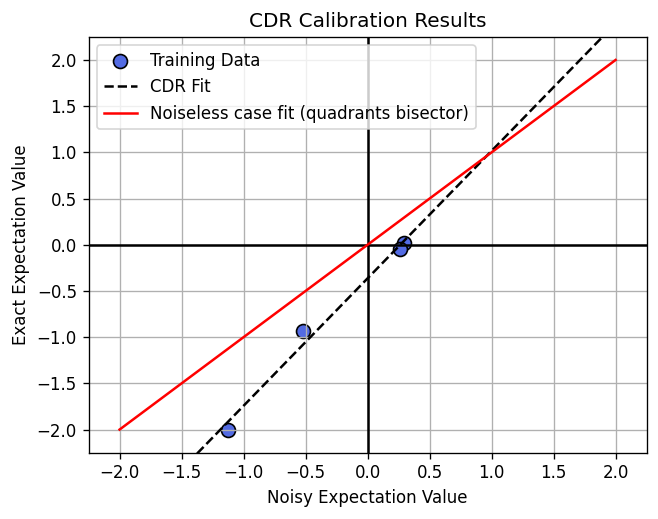

In [76]:
# Let's visualize the results of the CDR calibration
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6 * 6 / 8), dpi=120)
plt.vlines(0, -2.5, 2.5, color='black', ls='-')
plt.hlines(0, -2.5, 2.5, color='black', ls='-')
plt.scatter(training_data['x_noisy'], training_data['y_exact'], color="#536BE3", label='Training Data', edgecolors="black", s=70)
x_fit = np.linspace(-2, 2, 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='black', ls='--', label='CDR Fit')
plt.plot(x_fit, x_fit, color='red', ls='-', label='Noiseless case fit (quadrants bisector)')
plt.xlabel('Noisy Expectation Value')
plt.ylabel('Exact Expectation Value')
plt.title('CDR Calibration Results')
plt.legend()
plt.xlim(-2.25, 2.25)
plt.ylim(-2.25, 2.25)
plt.grid()
plt.show()

In [79]:
# Using the found noise map to mitigate the VQE result
mitigated_expval = slope * noisy_expval + intercept
print(mitigated_expval)

-1.9284354521502294


We managed to retrieve a better result 🎉